
🚀 STARTING: ADVERSARIAL STRESS-TEST 3C (WITHOUT TAUP PHASE ALIGNMENT)
⏳ Memuat database statistik Typical Embeddings 3C...

⏳ Mengekstrak jendela 3C tepat di Origin Time (Tanpa TauP)...


Processing 3C Unaligned Seismograms: 100%|██████████| 55699/55699 [45:49<00:00, 20.26it/s]    



📊================================== 3C VULNERABILITY TEST RESULTS (NO TAUP) ==================================

📈 MENJALANKAN MODUL VISUALISASI EVALUASI...


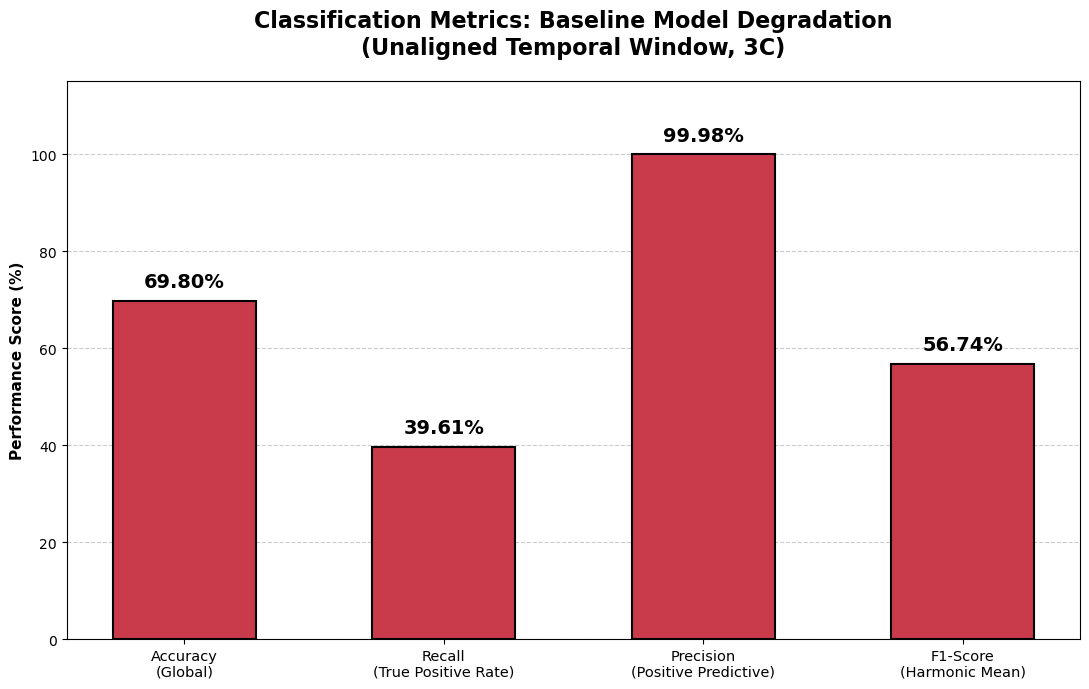

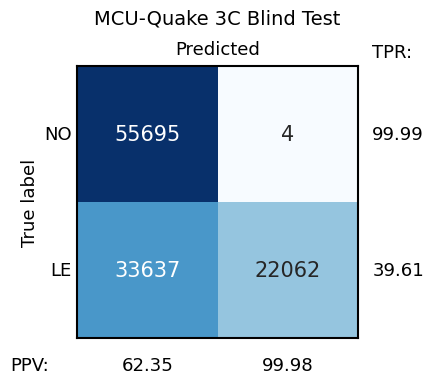

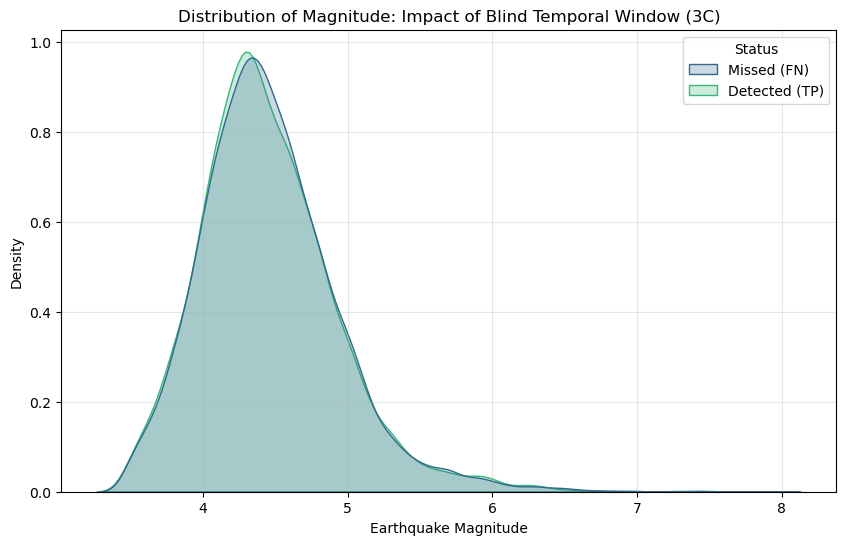

In [1]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'

# 🔥 NAMA LAPORAN DIUBAH KHUSUS UNTUK UJI 3C TANPA TAUP
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3C_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
except ImportError as e:
    print("❌ Gagal memuat Library.")
    sys.exit()

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

# ==============================================================================
# 📊 MODUL VISUALISASI LENGKAP (GAYA PAPER & JURNAL - ADAPTASI 3C)
# ==============================================================================
def plot_paper_style_cm(cm, title="MCU-Quake 3C Blind Test (No TauP)"):
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]

    TPR_NO = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0
    TPR_LE = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    PPV_NO = (TN / (TN + FN)) * 100 if (TN + FN) > 0 else 0.0
    PPV_LE = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['', ''], yticklabels=['NO', 'LE'], annot_kws={"size": 15}, ax=ax)

    ax.set_title(title, fontsize=14, pad=30, loc='center')
    ax.set_ylabel('True label', fontsize=13)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Predicted', fontsize=13, labelpad=5)
    plt.yticks(fontsize=13, rotation=0)
    ax.tick_params(axis='both', which='both', length=0)

    ax.text(2.1, -0.1, 'TPR:', fontsize=13, ha='left', va='center')
    ax.text(2.1, 0.5, f'{TPR_NO:.2f}', fontsize=13, ha='left', va='center')
    ax.text(2.1, 1.5, f'{TPR_LE:.2f}', fontsize=13, ha='left', va='center')
    ax.text(-0.2, 2.2, 'PPV:', fontsize=13, ha='right', va='center')
    ax.text(0.5, 2.2, f'{PPV_NO:.2f}', fontsize=13, ha='center', va='center')
    ax.text(1.5, 2.2, f'{PPV_LE:.2f}', fontsize=13, ha='center', va='center')

    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.savefig('paper_style_cm_3C.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_bar_metrics_paper_style(cm):
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    
    acc = ((TP + TN) / (TP + TN + FP + FN)) * 100
    rec = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    prec = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

    categories = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
    values = [acc, rec, prec, f1]

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.bar(categories, values, color='#c93b4a', edgecolor='black', linewidth=1.5, width=0.55)

    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylabel('Performance Score (%)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10.5)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_title("Classification Metrics: Baseline Model Degradation\n(Unaligned Temporal Window, 3C)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('bar_chart_metrics_degradation_3C.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualisasi_hasil_riset(report_path, catalog_path):
    print("\n📈 MENJALANKAN MODUL VISUALISASI EVALUASI...")
    df_report = pd.read_csv(report_path)
    df_catalog = pd.read_csv(catalog_path)
    
    y_true = df_report['Type'].apply(lambda x: 1 if 'LE' in x else 0).tolist()
    y_pred = df_report['Decision'].tolist()
    cm = confusion_matrix(y_true, y_pred)
    
    plot_bar_metrics_paper_style(cm)
    plot_paper_style_cm(cm, title="MCU-Quake 3C Blind Test")

    df_report['id'] = df_report['File'].astype(str).str.strip()
    col_id_cat = next((c for c in df_catalog.columns if 'id' in c.lower()), df_catalog.columns[0])
    df_catalog = df_catalog.rename(columns={col_id_cat: 'id'})
    df_catalog['id'] = df_catalog['id'].astype(str).str.strip()
    
    df_merged = df_report.merge(df_catalog, on='id', how='inner')
    df_gempa = df_merged[df_merged['Type'].str.contains('LE')].copy()
    df_gempa['Status'] = df_gempa['Decision'].apply(lambda x: 'Detected (TP)' if x == 1 else 'Missed (FN)')
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_gempa, x='magnitude', hue='Status', fill=True, common_norm=False, palette='viridis')
    plt.title('Distribution of Magnitude: Impact of Blind Temporal Window (3C)')
    plt.xlabel('Earthquake Magnitude')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    plt.savefig('magnitude_detection_density_3C.png', dpi=300)
    plt.show()

# ==============================================================================
# 🚀 CORE PROCESS: INFERENSI STRESS-TEST 3C
# ==============================================================================
def jalankan_stress_test_3C_tanpa_taup():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST 3C (WITHOUT TAUP PHASE ALIGNMENT)")
    print("="*90)
    
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    
    print("⏳ Memuat database statistik Typical Embeddings 3C...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak jendela 3C tepat di Origin Time (Tanpa TauP)...")
    for item in tqdm(daftar_file_mseed, desc="Processing 3C Unaligned Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean"); st.detrend("linear"); st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z")
            comp_n = st.select(component="N") or st.select(component="1")
            comp_e = st.select(component="E") or st.select(component="2")
            
            if not (comp_z and comp_n and comp_e): continue
            
            detik_origin_kaku = 60.0
            idx_start_le = int(detik_origin_kaku * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            le_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_le:idx_end_le])
            le_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_le:idx_end_le])
            
            emb_le_3c = np.array([utils.latent_codes_1D(le_z, embedding_model),
                                  utils.latent_codes_1D(le_n, embedding_model),
                                  utils.latent_codes_1D(le_e, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb_le_3c, embeddings_3C_PDFs, "Kernel")
            
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            no_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_no:idx_end_no])
            no_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_no:idx_end_no])
            
            emb_no_3c = np.array([utils.latent_codes_1D(no_z, embedding_model),
                                  utils.latent_codes_1D(no_n, embedding_model),
                                  utils.latent_codes_1D(no_e, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no_3c, embeddings_3C_PDFs, "Kernel")
            
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_3C_Unaligned', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO_3C_Unaligned', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    print("\n📊" + "="*34 + " 3C VULNERABILITY TEST RESULTS (NO TAUP) " + "="*34)
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    
    try:
        visualisasi_hasil_riset(PATH_FINAL_REPORT, PATH_KATALOG_MASTER)
    except Exception as e:
        print(f"⚠️ Visualisasi gagal dibuat. Error: {e}")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_3C_tanpa_taup()